Plots to describe the kinetic energy in the system.

I will look at the centre of the frame and compare it to the frame edges to describe how the energy is radiated away by inertial waves. Initially I will look at some static width and compare them.

I will then define some parameter where say 90% of the kinetic energy and see how that width changes with time.

I should also look at:
* time to peak kinetic energy
* value of peak kinetic energy
* show the frame of maximum kinetic energy - show that they look different.


In [15]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm
from scipy.ndimage import gaussian_filter
from scipy.signal import savgol_filter

#####Import Ollie Tools
dirPath = "C:/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)


####Import Ollie Tools MAC
# dirPath = "/Users/olliejackson/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)

oj.thesis_plot_settings()

C:/Coding
Thesis plot settings applied


time shape


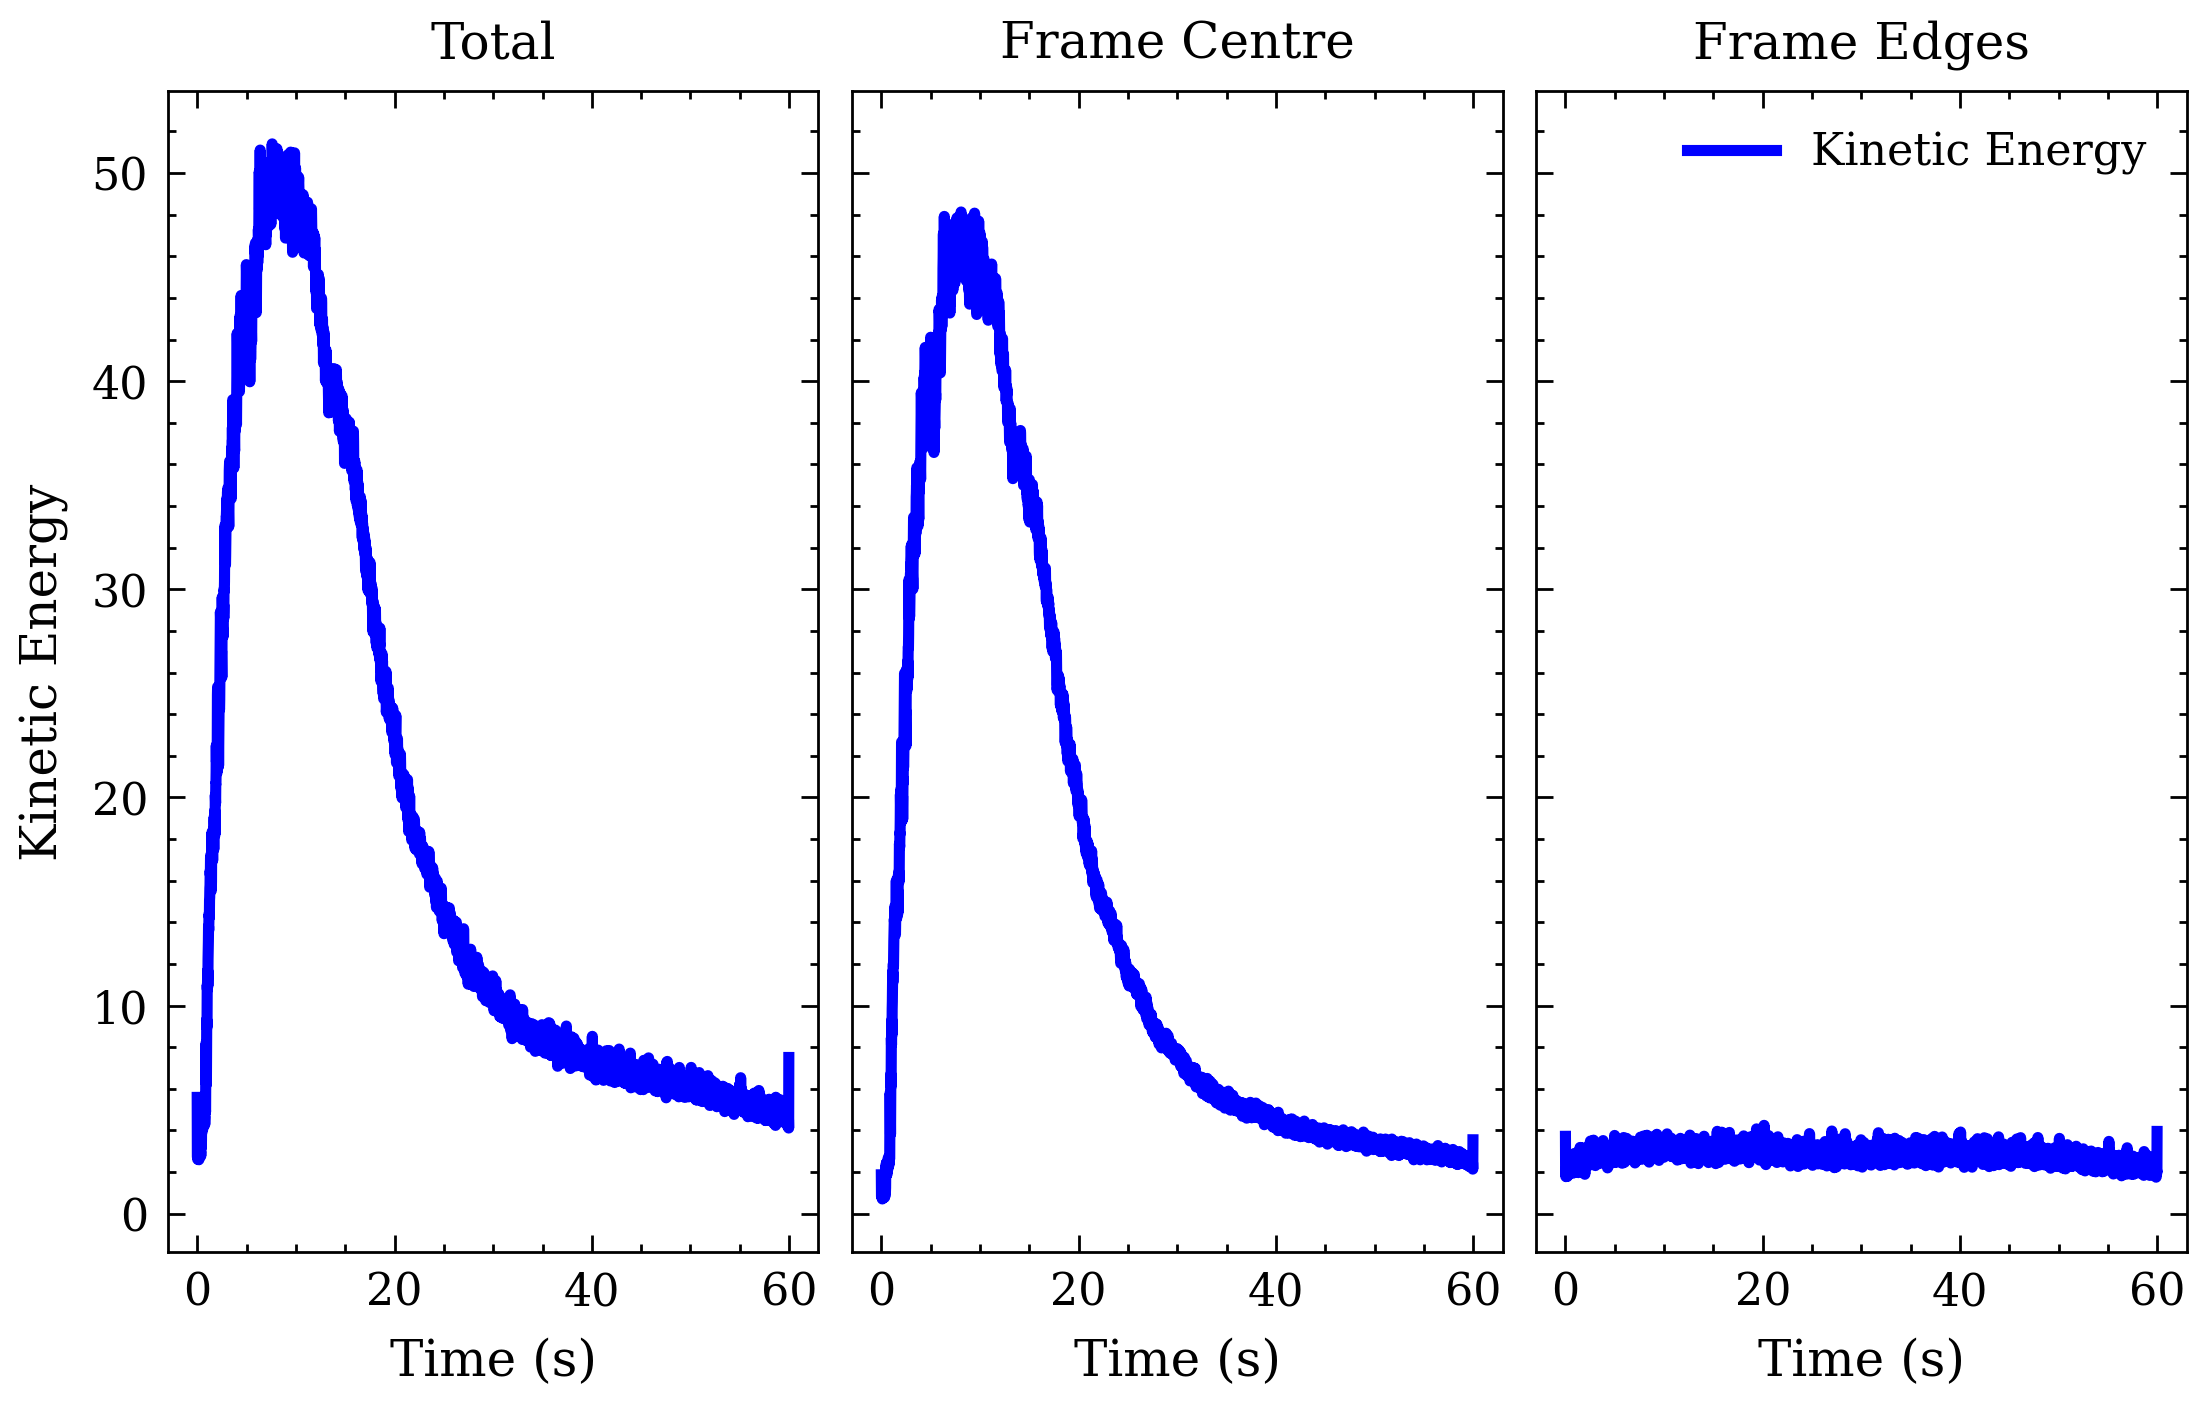

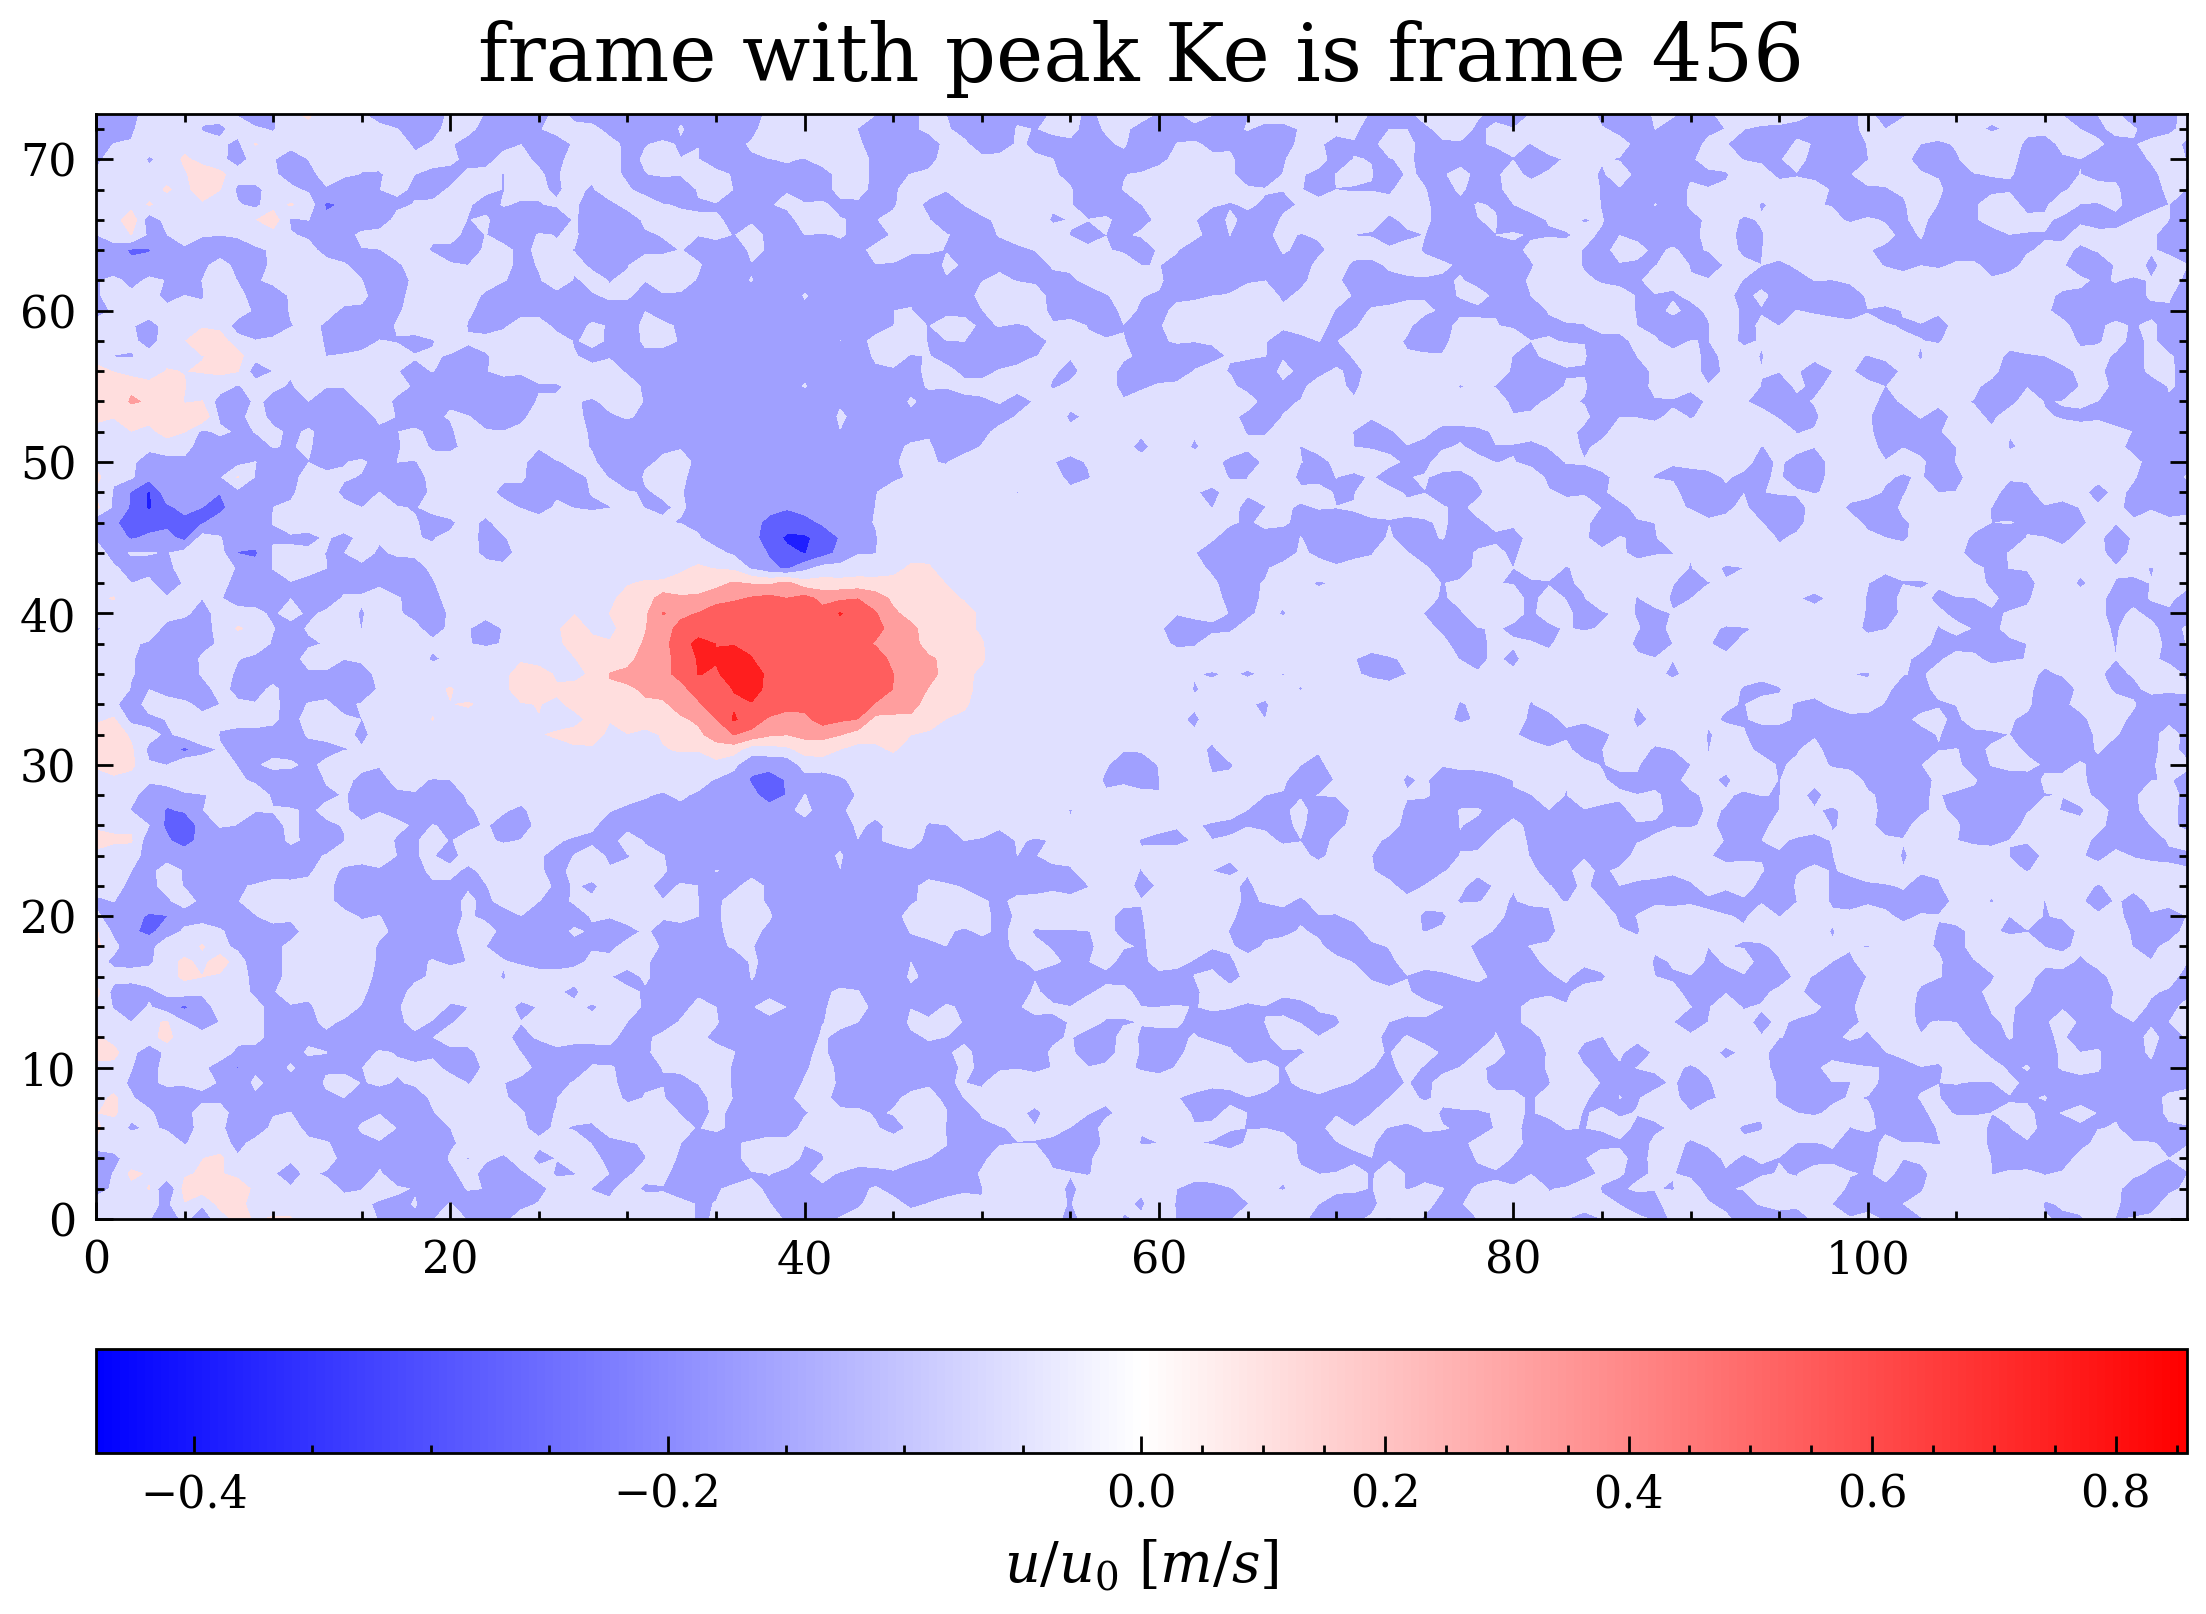

In [39]:
h5file = h5py.File('E:/H5/WideFOV.h5', 'r')
vels = h5file['Wide']['U200']['L100']['RPM0']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
h5file.close()
u_gaussian, v_gaussian = gaussian_filter(u, sigma=0.7), gaussian_filter(v, sigma=0.7)
r_nd, z_nd = oj.NDUnitsForPlotsWide(u.shape[1], u.shape[2])

time = oj.frames_to_seconds(u, v, 60)
print("time shape")
# print(time.shape)

#### Calculating kinetic energy ####
kinetic_energyt, sum_kinetic_energyt = oj.sum_kinetic_energy(u_gaussian[:,:,:], v_gaussian[:,:,:])
sum_kinetic_energy_max = max(sum_kinetic_energyt)
sum_kinetic_energy_max_location = np.argmax(sum_kinetic_energyt)

#### Kinetic Energy centre and sides####
kinetic_energy_left, sum_kinetic_energy_left = oj.sum_kinetic_energy(u_gaussian[:, :25,:], v_gaussian[:, :25,:])
kinetic_energy_mid, sum_kinetic_energy_mid = oj.sum_kinetic_energy(u_gaussian[:,25:50,:], v_gaussian[:,25:50,:])
kinetic_energy_right, sum_kinetic_energy_right = oj.sum_kinetic_energy(u_gaussian[:, 50: ,:], v_gaussian[:, 50: ,:])

sum_kinetic_energy_sides = sum_kinetic_energy_left + sum_kinetic_energy_right

resum_ke = sum_kinetic_energy_sides + sum_kinetic_energy_mid

# f1, (ax1, ax2) = plt.subplots(nrows=1,ncols=2)
# ax1.plot(sum_kinetic_energyt)
# ax1.set_title("sum_kinetic_energyt")
# ax2.plot(resum_ke)
# ax2.set_title("resum_ke")
# plt.show()

#### calculate vorticity and track ####

VortLocMax, VortLocMin = oj.vorticityPeakTracking(u_gaussian, v_gaussian, u.shape[0])
VortLocMax_sav = np.zeros([VortLocMax.shape[0], VortLocMax.shape[1]])
VortLocMax_sav[:,1] = oj.FilterSpikes(VortLocMax[:,1], 50)
VortLocMax_sav[:,1] = savgol_filter(VortLocMax_sav[:,1], 21, 7)
VortLocMax_sav[:,0] = oj.FilterSpikes(VortLocMax[:,0], 50)
VortLocMax_sav[:,0] = savgol_filter(VortLocMax_sav[:,0], 21, 7)

VortLocMin_sav = np.zeros([VortLocMin.shape[0], VortLocMin.shape[1]])
VortLocMin_sav[:,1] = oj.FilterSpikes(VortLocMin[:,1], 5)
VortLocMin_sav[:,1] = savgol_filter(VortLocMin_sav[:,1], 21, 7)
VortLocMin_sav[:,0] = oj.FilterSpikes(VortLocMin[:,0], 5)
VortLocMin_sav[:,0] = savgol_filter(VortLocMin_sav[:,0], 21, 7)

#### average ring position ####
vort_local_avg = np.mean([VortLocMax_sav, VortLocMin_sav], axis=0)



f1, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, sharex = True, sharey = True, figsize = (5.5, 3.5))
# plt.suptitle(f"Kinetic Energy against time 6RPM")
# ax1.plot(time[:780], vort_local_avg[:780,1], c = "C1", label = "Ring Position")
ax1.plot(time, sum_kinetic_energyt, c = "blue", label = "Kinetic Energy")
ax1.set_title("Total", fontsize=9)
ax1.set_xlabel("Time (s)", fontsize=9)
ax1.set_ylabel("Kinetic Energy", fontsize=9)
ax2.plot(time, sum_kinetic_energy_mid, c = "blue", label = "Kinetic Energy")
ax2.set_title("Frame Centre", fontsize=9)
ax2.set_xlabel("Time (s)", fontsize=9)
# ax2.set_ylabel("Kinetic Energy")
ax3.plot(time, sum_kinetic_energy_sides, c = "blue", label = "Kinetic Energy")
ax3.set_title("Frame Edges", fontsize=9)
ax3.set_xlabel("Time (s)", fontsize=9)
# ax3.set_ylabel("Kinetic Energy")
# ax1.legend()
# ax2.legend()
ax3.legend(fontsize = 8)




norm = colors.TwoSlopeNorm(vmin=np.min(u[sum_kinetic_energy_max_location, :, :]), vcenter=0, vmax=np.max(u[sum_kinetic_energy_max_location, :, :]))
f2, ax2 = plt.subplots(nrows=1, ncols=1)
plt.title(f"frame with peak Ke is frame {str(sum_kinetic_energy_max_location)}")
ax2.contourf(u[sum_kinetic_energy_max_location, :, :], cmap = 'bwr')
f1.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap='bwr'), ax=ax2, label=r'$u/u_{0} ~[m/s]$', location='bottom')
plt.show()



New Method with correct volume fraction

Text(0.5, 1.0, 'Old Method')

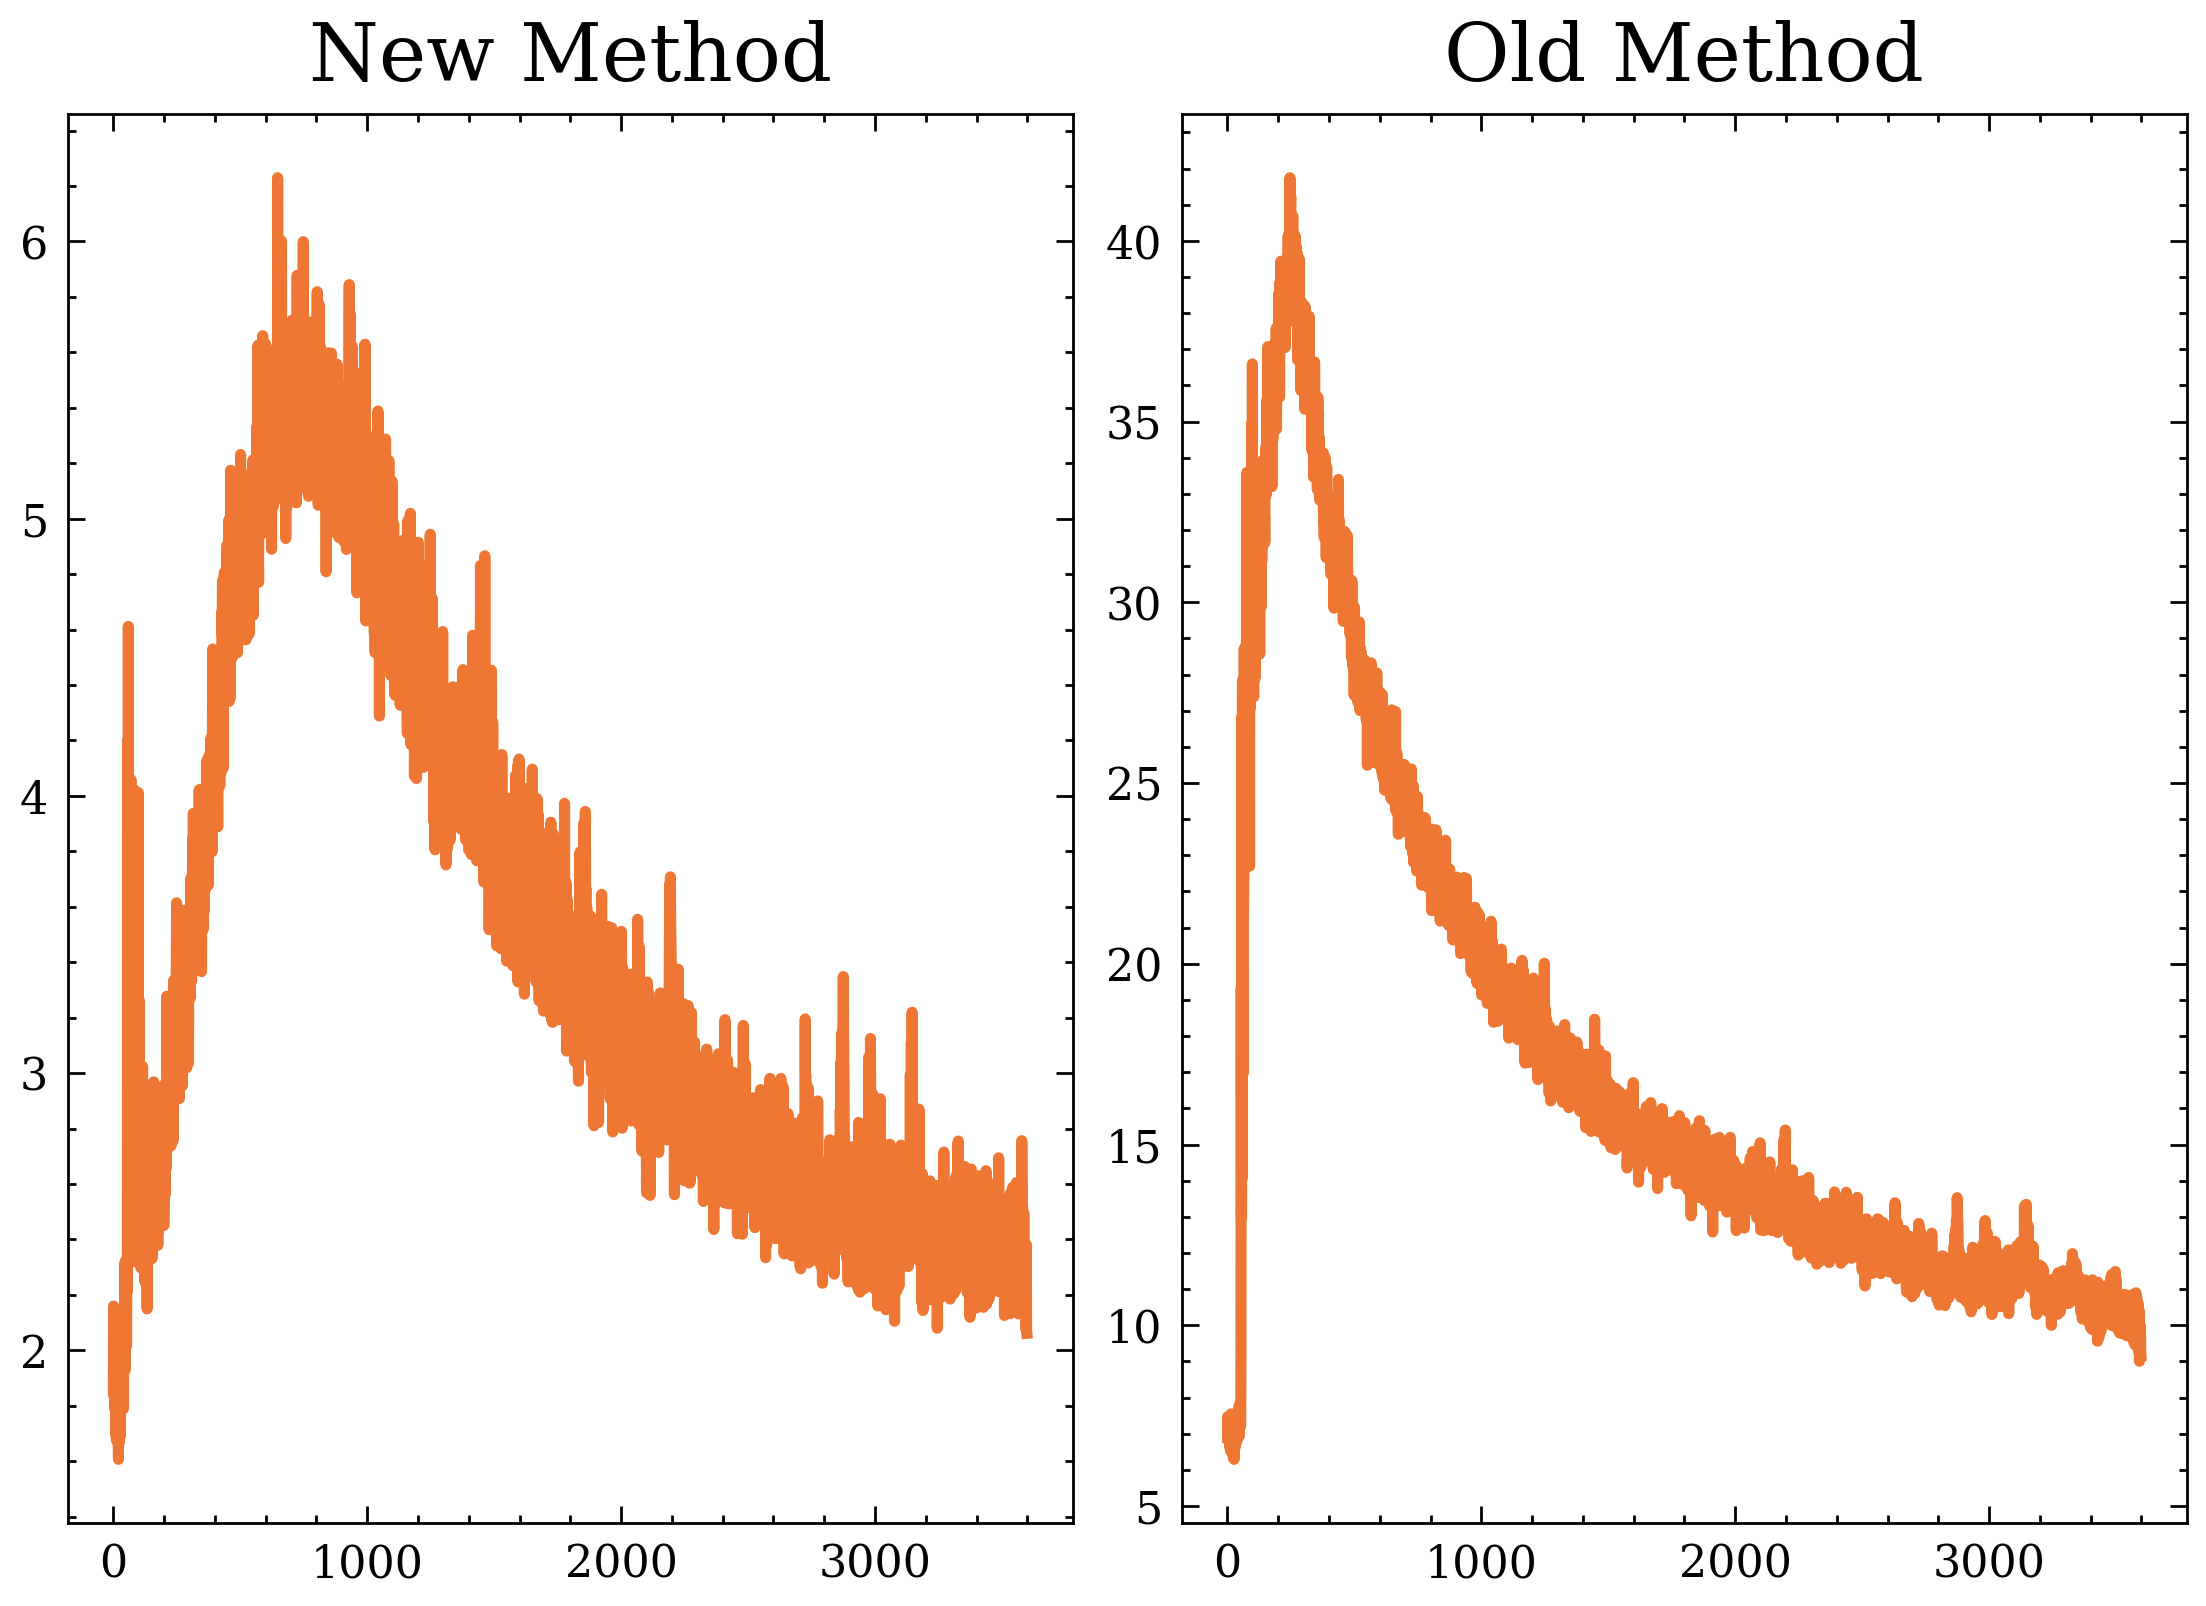

In [17]:
kinetic_energy, sum_kinetic_energy, Vol = oj.new_sum_kinetic(u, v)
r_d, z_d = oj.DimensionalScaleWide(u.shape[1], u.shape[2])


# scaled = u[500,:,:] * Vol
# fig, ax = plt.subplots(nrows=1, ncols=1)    
# # ax.contourf(z_d, r_d, scaled, cmap = 'bwr')
# plt.contourf(z_d, r_d, kinetic_energy[500,:,:], cmap = 'Blues')
# plt.colorbar()
# print(Vol[-1,:])


### old vs new method
ek, sum_ek, vol = oj.new_sum_kinetic(u, v)
ek_old, sum_ek_old = oj.sum_kinetic_energy(u, v)

f1, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
ax1.plot(sum_ek)
ax1.set_title("New Method")
ax2.plot(sum_ek_old)
ax2.set_title("Old Method")
